In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install -q prescient annoy scanpy

# Set data path
DATA_PATH = '/content/drive/MyDrive/LARRY/larry_preprocessed.h5ad'

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 41.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 44.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 149.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6

> **Notebook version:** `3.2.0` · **Updated:** 2026-06-03
>
> Confirm the imports cell prints the same version string before you run training.
> If it does not match, reload the Colab tab or `git pull` — you may be on a stale copy.
>
> **This version:** obs-based proliferation scoring · `FORCE_RETRAIN=True` (no stale checkpoint skip) · cell-cycle filter **OFF** · proliferation weights **ON** · evaluable-only simulation default

# PRESCIENT Trajectory Inference on LARRY Multi-Snapshot Data

PRESCIENT (Yeo et al. 2021) is a generative neural SDE trained on cells across multiple
time points. Unlike Palantir (notebook 02), it uses day-2, day-4, and day-6 cells from
the training wells to learn a differentiation landscape, then simulates trajectories
forward from the day-2 population to predict fate probabilities.

**Pipeline:**
1. Load preprocessed LARRY data (`larry_preprocessed.h5ad` from notebook 01)
2. Split training (Wells 0+1, `fate_train`) vs held-out test replicate (Well 2, days 4/6)
3. Build PRESCIENT input from `X_pca`, time labels, and cycling-gene proliferation scores
4. Train PRESCIENT on all training time points
5. Simulate forward from every day-2 cell (Well 0) and classify endpoints
6. Evaluate against clonal ground-truth fate labels (same metrics as notebook 02)


## 1. Imports


In [2]:
%matplotlib inline

# --- Notebook version (must match markdown banner at top) ---
NOTEBOOK_VERSION = "3.2.0"
NOTEBOOK_VERSION_DATE = "2026-06-03"

import sys
import os
import copy
import warnings
from types import SimpleNamespace
from collections import Counter
from time import strftime, localtime

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata
import torch
import torch.nn as optim
from annoy import AnnoyIndex
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from prescient.train.model import AutoGenerator
from prescient.train.util import init as prescient_init
from prescient.train.run import run as prescient_run
import prescient.commands.train_model as prescient_train_cmd

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

PREPROCESSED_H5AD = '/content/drive/MyDrive/LARRY/larry_preprocessed.h5ad'
OUTPUT_H5AD = "larry_day2_prescient.h5ad"
PRESCIENT_DATA_PT = "prescient_data/data.pt"
PRESCIENT_OUT_DIR = "prescient_models"
SAVED_MODEL_DIR = '/content/drive/MyDrive/LARRY/prescient_models'  # for RETRAIN=False fast re-runs

time_col = "Time point"
celltype_col = "Cell type annotation"
well_col = "Well"
clone_col = "clone_idx"
fate_prob_key = "prescient_fate_probabilities"

# Training hyperparameters (paper defaults; reduce TRAIN_EPOCHS for a quicker dry run)
PRETRAIN_EPOCHS = 500
TRAIN_EPOCHS = 2500
TRAIN_DT = 0.1
TRAIN_SD = 0.5
TRAIN_BATCH = 0.1
K_DIM = 500
LAYERS = 2
NUM_SIMS_PER_CELL = 10
SIM_BATCH_SIZE = 256

# Simulation scope: run only evaluable day-2 cells for speed by default.
# Set to False to simulate all day-2 cells.
SIM_EVALUABLE_ONLY = True
UMAP_SUBSAMPLE_N = 0  # kept for backward compatibility; ignored when SIM_EVALUABLE_ONLY=True

CYCLING_GENES = ["Mki67", "Top2a", "Pcna"]

# Weinreb / PRESCIENT paper cell-cycle markers (prescient-analysis)
CELL_CYCLE_GENES = [
    "Ube2c", "Hmgb2", "Hmgn2", "Tuba1b", "Ccnb1", "Tubb5", "Top2a", "Tubb4b",
]
MIN_CYCLE_CORR = 0.1

# Standard Tirosh/Regev S-phase and G2M cell-cycle gene lists (Seurat).
# Stored upper-case; gene lookup is case-insensitive so these match mouse
# Title-case symbols (Mcm5, Pcna, Top2a, ...). Used as a proliferation proxy
# when the hand-picked CYCLING_GENES are not present in var_names.
S_PHASE_GENES = [
    "MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2",
    "MCM6", "CDCA7", "DTL", "PRIM1", "UHRF1", "HELLS", "RFC2", "RPA2", "NASP",
    "RAD51AP1", "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7", "POLD3", "MSH2",
    "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6", "EXO1", "TIPIN", "DSCC1", "BLM",
    "CASP8AP2", "USP1", "CLSPN", "POLA1", "CHAF1B", "BRIP1", "E2F8",
]
G2M_GENES = [
    "HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80",
    "CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "CENPF", "TACC3", "FAM64A",
    "SMC4", "CCNB2", "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E",
    "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1", "CDC20", "TTK",
    "CDC25C", "KIF2C", "RANGAP1", "NCAPD2", "DLGAP5", "CDCA2", "CDCA8", "ECT2",
    "KIF23", "HMMR", "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5", "CENPE", "CTCF",
    "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA",
]
PROLIF_WEIGHT_MIN_STD = 0.01  # guard: per-timepoint proliferation weights must vary

# Ablation toggles (each change needs a retrain to compare). Setting BOTH to
# False reproduces the uniform-weight / no-filter baseline.
APPLY_CELL_CYCLE_FILTER = False   # drop HVGs correlated with the CELL_CYCLE_GENES markers before PCA
USE_PROLIFERATION_WEIGHTS = True  # growth-weight cells by proliferation (else uniform 0.5)

# Training mode: set RETRAIN=False to skip training and load model from Drive.
RETRAIN = False
# If retraining, optionally clear local output dir to avoid stale done.log skip.
FORCE_RETRAIN = True
N_PCS = 50
ANNOY_N_TREES = 10
ANNOY_N_NEIGHBORS = 20
PRED_CLASSES = [
    "Baso", "Ccr7_DC", "Eos", "Erythroid", "Lymphoid", "Mast", "Meg",
    "Monocyte", "Neutrophil", "pDC", "Other"
]

import prescient

print("=" * 55)
print(f"03_prescient.ipynb  v{NOTEBOOK_VERSION}  ({NOTEBOOK_VERSION_DATE})")
print(f"  APPLY_CELL_CYCLE_FILTER = {APPLY_CELL_CYCLE_FILTER}")
print(f"  USE_PROLIFERATION_WEIGHTS = {USE_PROLIFERATION_WEIGHTS}")
print(f"  RETRAIN                   = {RETRAIN}")
print(f"  FORCE_RETRAIN             = {FORCE_RETRAIN}")
print(f"  SIM_EVALUABLE_ONLY        = {SIM_EVALUABLE_ONLY}")
print("=" * 55)
print(f"Python: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"PRESCIENT: {prescient.__version__ if hasattr(prescient, '__version__') else 'installed'}")


[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK
03_prescient.ipynb  v3.2.0  (2026-06-03)
  APPLY_CELL_CYCLE_FILTER = False
  USE_PROLIFERATION_WEIGHTS = True
  FORCE_RETRAIN             = True
  SIMULATE_EVALUABLE_ONLY   = True
Python: /usr/bin/python3
PyTorch: 2.11.0+cu128
PRESCIENT: installed


## 2. Load preprocessed data


In [3]:
adata_full = anndata.read_h5ad(PREPROCESSED_H5AD)
print(adata_full)
print("\nobs columns:", list(adata_full.obs.columns))
print("obsm keys:  ", list(adata_full.obsm.keys()))


AnnData object with n_obs × n_vars = 130887 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'S_score', 'G2M_score', 'phase', 'proliferation_score', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cellcycle_genes', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_cellcycle', 'X_clone', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'connectivities', 'distances'

obs columns: ['Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'tota

## 3. Training vs test replicate split

Following Weinreb et al. 2020 / notebook 01:
- **Training (`fate_train`)**: Wells 0 and 1 at all time points (days 2, 4, 6)
- **Held-out test replicate**: Well 2 on days 4 and 6 (not used for PRESCIENT training)

Day-2 cells all reside in Well 0; we simulate forward from that population and
evaluate on clonal ground-truth labels stored in `fate_frac_*` columns.


In [4]:
train_mask = adata_full.obs["fate_train"].astype(bool)
test_mask = (adata_full.obs[well_col] == 2) & (adata_full.obs[time_col] > 2)

adata_train = adata_full[train_mask].copy()
adata_test_rep = adata_full[test_mask].copy()
adata_d2 = adata_full[adata_full.obs[time_col] == 2].copy()

print(f"Training cells (Wells 0+1): {adata_train.n_obs:,}")
print(f"  Day 2: {(adata_train.obs[time_col] == 2).sum():,}")
print(f"  Day 4: {(adata_train.obs[time_col] == 4).sum():,}")
print(f"  Day 6: {(adata_train.obs[time_col] == 6).sum():,}")
print(f"Held-out Well 2 (days 4/6): {adata_test_rep.n_obs:,}")
print(f"Day-2 cells for simulation (Well 0): {adata_d2.n_obs:,}")

if clone_col in adata_d2.obs.columns:
    n_cloned = (adata_d2.obs[clone_col].fillna(-1).astype(int) >= 0).sum()
    print(f"  With clonal lineage info: {n_cloned:,} ({100 * n_cloned / adata_d2.n_obs:.1f}%)")


Training cells (Wells 0+1): 74,060
  Day 2: 28,249
  Day 4: 21,300
  Day 6: 24,511
Held-out Well 2 (days 4/6): 56,827
Day-2 cells for simulation (Well 0): 28,249
  With clonal lineage info: 4,638 (16.4%)


## 4. PRESCIENT input preparation

Following `gifford-lab/prescient-analysis` (Weinreb 2020 fate task): remove HVGs correlated
with cell-cycle markers (`min_corr=0.1`), scale the filtered `log1p_norm` matrix, and
fit **50 PCs** on training cells (Wells 0+1). Physical time points {2, 4, 6} map to
PRESCIENT indices `0, 1, 2`.

Proliferation weights use `Mki67`, `Top2a`, `Pcna` from `log1p_norm` (uniform fallback
if absent).


In [5]:
def _var_name_map(adata):
    """lower-cased var_name -> actual var_name (case-insensitive gene lookup)."""
    return {str(n).lower(): str(n) for n in adata.var_names}


def resolve_gene_names(adata, names):
    """Resolve a list of gene symbols against adata.var_names, ignoring case.

    Returns (found_actual_names, missing_names). This is the central fix for the
    silent-failure bug: the markers in this notebook are Title-case mouse symbols
    while var_names may differ in case, so exact `g in var_names` checks missed
    every gene and the code fell back to no-ops.
    """
    name_map = _var_name_map(adata)
    found, missing = [], []
    for g in names:
        actual = name_map.get(str(g).lower())
        if actual is not None:
            found.append(actual)
        else:
            missing.append(g)
    return found, missing


def get_gene_expr(adata, gene_name, prefer_layer="log1p_norm"):
    """Dense expression for gene_name (case-insensitive); prefers log1p_norm over X."""
    found, _ = resolve_gene_names(adata, [gene_name])
    if not found:
        return None
    idx = adata.var_names.get_loc(found[0])
    if prefer_layer in adata.layers:
        col = adata.layers[prefer_layer][:, idx]
    else:
        col = adata.X[:, idx]
    return np.asarray(col.todense()).flatten() if sp.issparse(col) else np.asarray(col).flatten()


def _layer_matrix(adata, gene_idx=None, layer="log1p_norm"):
    """Dense (cells × genes) matrix from a layer, optionally gene-subset."""
    if layer in adata.layers:
        X = adata.layers[layer]
    else:
        X = adata.X
    if sp.issparse(X):
        X = np.asarray(X.todense())
    else:
        X = np.asarray(X)
    if gene_idx is not None:
        X = X[:, gene_idx]
    return X


def remove_cell_cycle_correlated_genes(
    adata, cell_cycle_genes, min_corr=0.1, layer="log1p_norm"
):
    """Drop HVGs whose |r| with any cell-cycle marker is >= min_corr.

    Markers are taken from adata.obsm['X_cellcycle'] when present (written by
    notebook 01 WITHOUT altering the shared HVG matrix), otherwise looked up in
    var (case-insensitive, with an S/G2M-signature fallback)."""
    X = _layer_matrix(adata, layer=layer)

    if "X_cellcycle" in adata.obsm:
        cc_full = np.asarray(adata.obsm["X_cellcycle"], dtype=float)
        cc_full_names = list(adata.uns.get("cellcycle_genes", [f"cc_{i}" for i in range(cc_full.shape[1])]))
        # Use ONLY the prescient-analysis markers (cell_cycle_genes) as removal
        # anchors. obsm holds the full ~97-gene signature for proliferation
        # scoring; using all of it here over-removes genes (~245/2000) and
        # degrades the embedding. Restricting to the 8 markers matches Issue 2.
        _want = {g.lower() for g in cell_cycle_genes}
        _sel = [k for k, n in enumerate(cc_full_names) if str(n).lower() in _want]
        if _sel:
            cc_X = cc_full[:, _sel]
            cc_names = [cc_full_names[k] for k in _sel]
        else:
            cc_X = cc_full
            cc_names = cc_full_names
        print(f"Cell-cycle markers from obsm['X_cellcycle']: using {cc_X.shape[1]} of "
              f"{cc_full.shape[1]} signature genes as removal anchors ({cc_names}).")
    else:
        cc_present, cc_missing = resolve_gene_names(adata, cell_cycle_genes)
        print(
            f"Cell-cycle markers resolved in var: {len(cc_present)}/{len(cell_cycle_genes)} "
            f"present={cc_present} missing={cc_missing}"
        )
        if not cc_present:
            cc_present, _ = resolve_gene_names(adata, S_PHASE_GENES + G2M_GENES)
            print(f"  Falling back to standard S/G2M signature: {len(cc_present)} markers found.")
        if not cc_present:
            print(f"No cell cycle markers available — keeping all {adata.n_vars} genes.")
            return np.arange(adata.n_vars)
        cc_idx = [adata.var_names.get_loc(g) for g in cc_present]
        cc_X = X[:, cc_idx]
        cc_names = cc_present

    n_markers = cc_X.shape[1]
    keep = np.ones(adata.n_vars, dtype=bool)
    for j in range(adata.n_vars):
        corrs = []
        for k in range(n_markers):
            r = np.corrcoef(X[:, j], cc_X[:, k])[0, 1]
            if not np.isnan(r):
                corrs.append(abs(r))
        if corrs and max(corrs) >= min_corr:
            keep[j] = False

    n_removed = int((~keep).sum())
    print(
        f"Cell-cycle filter (|r|>={min_corr}): removed {n_removed} / {adata.n_vars} genes "
        f"using {n_markers} markers."
    )
    # Issue 2 guard: the filter must actually drop genes.
    assert n_removed >= 1, (
        f"Cell-cycle filter removed 0 genes — no HVG correlates with the {n_markers} "
        f"cell-cycle markers above |r|={min_corr}. Check obsm['X_cellcycle'] / markers."
    )
    return np.where(keep)[0]


def fit_prescient_pca_pipeline(adata_fit, layer="log1p_norm", n_comps=N_PCS):
    """Fit gene mask, scaler, and PCA on training cells (prescient-analysis style)."""
    if APPLY_CELL_CYCLE_FILTER:
        gene_idx = remove_cell_cycle_correlated_genes(
            adata_fit, CELL_CYCLE_GENES, MIN_CYCLE_CORR, layer
        )
    else:
        print(f"Cell-cycle filter disabled (APPLY_CELL_CYCLE_FILTER=False) — "
              f"using all {adata_fit.n_vars} genes for PCA.")
        gene_idx = np.arange(adata_fit.n_vars)
    X_fit = _layer_matrix(adata_fit, gene_idx=gene_idx, layer=layer)
    scaler = StandardScaler()
    scaler.fit(X_fit)
    pca = PCA(n_components=n_comps, random_state=SEED)
    pca.fit(scaler.transform(X_fit))
    return gene_idx, scaler, pca


def transform_prescient_pca(adata, gene_idx, scaler, pca, layer="log1p_norm"):
    X = _layer_matrix(adata, gene_idx=gene_idx, layer=layer)
    return pca.transform(scaler.transform(X))


# Physical days in metadata; PRESCIENT package uses consecutive integer indices
TP_VALUES = [2.0, 4.0, 6.0]
TP_TO_IDX = {tp: i for i, tp in enumerate(TP_VALUES)}


def build_prescient_tensors(adata, tp_values=TP_VALUES):
    """Return xp list (per time index), y index list, and per-cell metadata arrays."""
    xp_list = []
    meta_tp = []
    meta_ct = []
    cell_names = []

    for tp in tp_values:
        mask = (adata.obs[time_col] == tp).values
        xp_list.append(torch.from_numpy(adata.obsm["X_pca"][mask]).float())
        meta_tp.extend([TP_TO_IDX[tp]] * int(mask.sum()))
        ct = adata.obs.loc[mask, celltype_col].astype(str).fillna("Unlabeled").values
        meta_ct.extend(ct.tolist())
        cell_names.extend(adata.obs_names[mask].tolist())

    y_idx = list(range(len(tp_values)))
    return xp_list, y_idx, np.array(meta_tp), np.array(meta_ct), cell_names


def get_full_gene_adata(adata, layer="log1p_norm"):
    """Return (AnnData, label) using the fullest gene set available.

    The preprocessed file is subset to HVGs, so cell-cycle/cycling genes may be
    missing from the main matrix. If a fuller gene set lives in adata.raw, use
    it; otherwise fall back to the HVG matrix (log1p_norm layer or X)."""
    if adata.raw is not None and adata.raw.n_vars > adata.n_vars:
        Xr = adata.raw.X
        Xr = np.asarray(Xr.todense()) if sp.issparse(Xr) else np.asarray(Xr)
        src = anndata.AnnData(X=Xr.copy(), obs=adata.obs.copy())
        src.var_names = list(adata.raw.var_names)
        return src, f"adata.raw ({src.n_vars} genes, full transcriptome)"
    src = anndata.AnnData(X=_layer_matrix(adata, layer=layer).copy(), obs=adata.obs.copy())
    src.var_names = list(adata.var_names)
    where = layer if layer in adata.layers else "X"
    return src, f"{where} ({src.n_vars} genes, HVG-subset)"


def compute_proliferation_score(adata, layer="log1p_norm"):
    """Per-cell proliferation score with a robust fallback.

    1) Sum of normalized expression of the hand-picked CYCLING_GENES, looked up
       case-insensitively from the fullest available gene set.
    2) If none are present, fall back to a Tirosh/Regev S-phase + G2M
       `sc.tl.score_genes` proxy over whatever signature genes overlap var_names.

    Returns (scores, method_label)."""
    # 0) Preferred: proliferation score precomputed on the FULL gene set in
    #    notebook 01 (the HVG-only file does not contain the cycling genes).
    if "proliferation_score" in adata.obs:
        s = np.asarray(adata.obs["proliferation_score"].values, dtype=float)
        if np.isfinite(s).any() and np.nanstd(s) > 0:
            print("Proliferation from precomputed adata.obs['proliferation_score'] "
                  "(scored on full gene set in notebook 01).")
            return s, "obs:proliferation_score"
    if "S_score" in adata.obs and "G2M_score" in adata.obs:
        s = np.maximum(
            np.asarray(adata.obs["S_score"].values, dtype=float),
            np.asarray(adata.obs["G2M_score"].values, dtype=float),
        )
        if np.nanstd(s) > 0:
            print("Proliferation from precomputed adata.obs S_score/G2M_score (notebook 01).")
            return s, "obs:S/G2M"

    src, src_label = get_full_gene_adata(adata, layer=layer)

    found, missing = resolve_gene_names(src, CYCLING_GENES)
    if found:
        idx = [src.var_names.get_loc(g) for g in found]
        X = src.X[:, idx]
        X = np.asarray(X.todense()) if sp.issparse(X) else np.asarray(X)
        scores = np.zeros(src.n_obs, dtype=float)
        for j in range(X.shape[1]):
            mx = X[:, j].max()
            if mx > 0:
                scores += X[:, j] / mx
        print(f"Proliferation from cycling genes {found} (missing {missing}) via {src_label}")
        return scores, f"cycling_genes:{found}"

    s_found, _ = resolve_gene_names(src, S_PHASE_GENES)
    g_found, _ = resolve_gene_names(src, G2M_GENES)
    print(
        f"Hand-picked cycling genes {CYCLING_GENES} absent in {src_label}. "
        f"Falling back to score_genes proxy: {len(s_found)} S-phase + {len(g_found)} G2M genes found."
    )
    assert (len(s_found) + len(g_found)) >= 3, (
        "Too few proliferation genes available for a score_genes proxy "
        f"(S={s_found}, G2M={g_found}). The cell-cycle genes are not in this "
        "HVG-only file and there is no adata.obs['proliferation_score']. "
        "Re-run notebook 01 (it now scores the cell cycle on the full gene set "
        "and persists proliferation_score / S_score / G2M_score) to regenerate "
        "larry_preprocessed.h5ad, then re-run this notebook."
    )
    parts = []
    if s_found:
        sc.tl.score_genes(src, s_found, score_name="S_score", random_state=SEED)
        parts.append(np.asarray(src.obs["S_score"].values, dtype=float))
    if g_found:
        sc.tl.score_genes(src, g_found, score_name="G2M_score", random_state=SEED)
        parts.append(np.asarray(src.obs["G2M_score"].values, dtype=float))
    scores = np.maximum.reduce(parts) if len(parts) > 1 else parts[0]
    return scores.astype(float), f"score_genes_proxy(S={len(s_found)},G2M={len(g_found)})"


def compute_proliferation_weights(adata, xp_all, meta_tp):
    """Per-cell proliferation score → per-timepoint weight vectors for PRESCIENT."""
    if not USE_PROLIFERATION_WEIGHTS:
        print("Proliferation weighting disabled (USE_PROLIFERATION_WEIGHTS=False) — uniform 0.5.")
        w_list = [
            torch.full((int((meta_tp == tp_i).sum()),), 0.5, dtype=torch.float32)
            for tp_i in range(len(TP_VALUES))
        ]
        return w_list, np.full(adata.n_obs, 0.5, dtype=float)

    scores, prolif_method = compute_proliferation_score(adata)

    xp_np = xp_all.astype(np.float32)
    ay = AnnoyIndex(xp_np.shape[1], "euclidean")
    for i in range(xp_np.shape[0]):
        ay.add_item(i, xp_np[i])
    ay.build(ANNOY_N_TREES)

    beta = 0.1
    smoothed = scores.copy()
    prev = scores.copy()
    for _ in range(5):
        cur = np.zeros_like(prev)
        for i in range(len(prev)):
            nn = prev[ay.get_nns_by_item(i, ANNOY_N_NEIGHBORS)]
            cur[i] = beta * nn[0] + (1 - beta) * nn[1:].mean()
        prev = cur
        smoothed = cur

    smin, smax = smoothed.min(), smoothed.max()
    if smax > smin:
        smoothed = (smoothed - smin) / (smax - smin)
    else:
        smoothed = np.ones_like(smoothed) * 0.5

    w_list = []
    for tp_i in range(len(TP_VALUES)):
        m = meta_tp == tp_i
        w_list.append(torch.from_numpy(smoothed[m].astype(np.float32)))

    # Issue 1 guard: weights must carry real proliferation signal. A near-zero
    # std means we silently fell back to uniform (the original bug).
    w_stds = [float(w.numpy().std()) for w in w_list]
    for tp_i, s in enumerate(w_stds):
        assert s > PROLIF_WEIGHT_MIN_STD, (
            f"Proliferation weights at time index {tp_i} are ~uniform "
            f"(std={s:.4f} <= {PROLIF_WEIGHT_MIN_STD}). Proliferation weighting "
            f"silently fell back to uniform — check gene lookup / source matrix."
        )
    print(f"Proliferation method: {prolif_method}")
    print(f"Per-timepoint weight std: {[round(s, 3) for s in w_stds]} (all > {PROLIF_WEIGHT_MIN_STD})")
    return w_list, smoothed


# --- Gene-naming diagnostics (root-cause check for the silent no-ops) ---
print("=" * 60)
print("GENE-NAMING DIAGNOSTICS")
print("=" * 60)
print(f"adata_train: {adata_train.n_obs:,} cells x {adata_train.n_vars:,} genes")
print(f"var index name: {adata_train.var.index.name}")
print(f"layers present: {list(adata_train.layers.keys())}")
print(f"adata.raw present: {adata_train.raw is not None}"
      + (f" ({adata_train.raw.n_vars:,} genes)" if adata_train.raw is not None else ""))
print(f"\nSample of 20 var_names: {list(adata_train.var_names[:20])}")

print("\nExact (case-sensitive) membership of cycling genes in var_names:")
for g in CYCLING_GENES:
    print(f"  {g:8s} exact={g in set(adata_train.var_names)}")
_found_ci, _miss_ci = resolve_gene_names(adata_train, CYCLING_GENES)
print(f"Case-insensitive resolution -> found={_found_ci} missing={_miss_ci}")
_cc_found, _cc_miss = resolve_gene_names(adata_train, CELL_CYCLE_GENES)
print(f"Cell-cycle markers case-insensitive -> {len(_cc_found)}/{len(CELL_CYCLE_GENES)} found={_cc_found}")
_s_found, _ = resolve_gene_names(adata_train, S_PHASE_GENES)
_g_found, _ = resolve_gene_names(adata_train, G2M_GENES)
print(f"Standard signature overlap -> {len(_s_found)} S-phase, {len(_g_found)} G2M genes in var")
_prolif_cols = [c for c in ("proliferation_score", "S_score", "G2M_score", "phase") if c in adata_train.obs]
print(f"Precomputed cell-cycle obs columns (from notebook 01): {_prolif_cols if _prolif_cols else 'NONE — re-run notebook 01'}")
_has_ccm = "X_cellcycle" in adata_train.obsm
print("obsm['X_cellcycle'] present: " + (f"YES ({adata_train.obsm['X_cellcycle'].shape[1]} marker genes)" if _has_ccm else "NO — re-run notebook 01"))
print("=" * 60)

# Recompute PCA after cell-cycle gene removal (do not use notebook 01 X_pca)
prescient_gene_idx, prescient_scaler, prescient_pca = fit_prescient_pca_pipeline(adata_train)
for _ad in (adata_train, adata_d2):
    _ad.obsm["X_pca"] = transform_prescient_pca(
        _ad, prescient_gene_idx, prescient_scaler, prescient_pca
    )
print(f"PRESCIENT PCA: {N_PCS} components on {len(prescient_gene_idx)} genes (after cell-cycle filter)")

xp_train, y_idx, meta_tp, meta_ct, train_names = build_prescient_tensors(adata_train)
xp_all_train = adata_train.obsm["X_pca"]
w_list, growth_scores = compute_proliferation_weights(adata_train, xp_all_train, meta_tp)

print(f"PRESCIENT tensors: {len(xp_train)} time slices")
for i, tp in enumerate(TP_VALUES):
    print(f"  index {i} (day {int(tp)}): {xp_train[i].shape[0]:,} cells, w mean={w_list[i].mean():.3f}")

os.makedirs(os.path.dirname(PRESCIENT_DATA_PT) or ".", exist_ok=True)
torch.save({
    "xp": xp_train,
    "y": y_idx,
    "y_days": TP_VALUES,
    "w": w_list,
    "celltype": meta_ct,
    "tps": meta_tp,
    "names": train_names,
}, PRESCIENT_DATA_PT)
print(f"Saved PRESCIENT data to {PRESCIENT_DATA_PT}")



GENE-NAMING DIAGNOSTICS
adata_train: 74,060 cells x 2,000 genes
var index name: gene_ids
layers present: ['counts_norm', 'log1p_norm']
adata.raw present: False

Sample of 20 var_names: ['0610043K17Rik', '1600012P17Rik', '1700001C19Rik', '1700001J03Rik', '1700001O22Rik', '1700003L19Rik', '1700008K24Rik', '1700010K24Rik', '1700011C11Rik', '1700011H14Rik', '1700012L04Rik', '1700016F12Rik', '1700016G22Rik', '1700016K19Rik', '1700017J07Rik', '1700018F24Rik', '1700022A21Rik', '1700022A22Rik', '1700022E09Rik', '1700024B05Rik']

Exact (case-sensitive) membership of cycling genes in var_names:
  Mki67    exact=False
  Top2a    exact=False
  Pcna     exact=False
Case-insensitive resolution -> found=[] missing=['Mki67', 'Top2a', 'Pcna']
Cell-cycle markers case-insensitive -> 0/8 found=[]
Standard signature overlap -> 0 S-phase, 0 G2M genes in var
Precomputed cell-cycle obs columns (from notebook 01): ['proliferation_score', 'S_score', 'G2M_score', 'phase']
obsm['X_cellcycle'] present: YES (97 mar

## 5. Train PRESCIENT

Train on all `fate_train` cells across time indices 0 → 1 → 2 (days 2 → 4 → 6).


In [6]:
def prescient_train_init(args):
    """Build training config from data.pt (mirrors prescient.commands.train_model.train_init)."""
    data_pt = torch.load(args.data_path, weights_only=False)
    x = data_pt["xp"]
    y = data_pt["y"]
    weight = data_pt["w"]

    a = copy.copy(args)
    if args.weight_name is not None:
        a.weight = args.weight_name

    name = (
        "{weight}-{activation}_{layers}_{k_dim}-{train_tau}"
    ).format(**a.__dict__)

    a.out_dir = os.path.join(args.out_dir, name, f"seed_{a.seed}")
    config = prescient_train_cmd.init_config(a)

    config.x_dim = x[0].shape[-1]
    config.t = y[-1] - y[0]
    config.start_t = y[0]
    config.train_t = y[1:]

    y_start = y[config.start_t]
    y_ = [yy for yy in y if yy > y_start]
    w_ = weight[config.start_t]
    w = {(y_start, yy): torch.from_numpy(np.exp((yy - y_start) * w_.numpy())) for yy in y_}

    return x, y, w, config


class TrainArgs(SimpleNamespace):
    pass


train_args = TrainArgs(
    seed=SEED,
    gpu=0,
    no_cuda=not torch.cuda.is_available(),
    data_path=PRESCIENT_DATA_PT,
    out_dir=PRESCIENT_OUT_DIR,
    weight_name="cycling",
    loss="euclidean",
    k_dim=K_DIM,
    activation="softplus",
    layers=LAYERS,
    pretrain_epochs=PRETRAIN_EPOCHS,
    train_epochs=TRAIN_EPOCHS,
    train_lr=0.01,
    train_dt=TRAIN_DT,
    train_sd=TRAIN_SD,
    train_tau=1e-6,
    train_batch=TRAIN_BATCH,
    train_clip=0.25,
    save=500,
    pretrain=True,
    train=True,
)

os.makedirs(PRESCIENT_OUT_DIR, exist_ok=True)

# PRESCIENT skips training if done.log exists in the output dir. When the PCA
# or proliferation weights change, the old checkpoint is stale — wipe it first.
_model_name = (
    f"{train_args.weight_name}-{train_args.activation}_{train_args.layers}_"
    f"{train_args.k_dim}-{train_args.train_tau}"
)
_model_dir = os.path.join(PRESCIENT_OUT_DIR, _model_name, f"seed_{SEED}")
if RETRAIN:
    if FORCE_RETRAIN and os.path.isdir(_model_dir):
        import shutil
        print(f"FORCE_RETRAIN=True — removing stale model dir: {_model_dir}")
        shutil.rmtree(_model_dir)
    elif os.path.exists(os.path.join(_model_dir, "done.log")):
        print(
            f"WARNING: done.log exists at {_model_dir} — PRESCIENT will skip training "
            f"and reuse a stale checkpoint. Set FORCE_RETRAIN=True to retrain."
        )

    print(f"Training PRESCIENT ({TRAIN_EPOCHS} epochs, seed={SEED}) ...")
    prescient_run(train_args, prescient_train_init)
    print("Training complete.")
else:
    print("RETRAIN=False — skipping training; loading existing model from Drive in section 6.")


Training PRESCIENT (2500 epochs, seed=42) ...
Making directory at prescient_models/cycling-softplus_2_500-1e-06/seed_42
AutoGenerator(
  (net): Sequential(
    (linear1): Linear(in_features=50, out_features=500, bias=True)
    (softplus1): Softplus(beta=1.0, threshold=20.0)
    (linear2): Linear(in_features=500, out_features=500, bias=True)
    (softplus2): Softplus(beta=1.0, threshold=20.0)
    (linear): Linear(in_features=500, out_features=1, bias=False)
  )
)


[seed_42|pretrain] 499 -0.074: 100%|██████████| 500/500 [00:39<00:00, 12.78it/s]
[seed_42|train] 2500 26.254345 40.979942 33.617144 21.634295: 100%|██████████| 2500/2500 [13:04<00:00,  3.19it/s]

Training complete.


## 6. Load trained model and reference classifier

We classify simulated endpoints by k-nearest neighbors in PCA space against **training**
cells with a cell-type annotation (Wells 0+1, all time points).


In [7]:
# Locate trained model directory
model_name = (
    f"{train_args.weight_name}-{train_args.activation}_{train_args.layers}_{train_args.k_dim}-{train_args.train_tau}"
)
if RETRAIN:
    model_dir = os.path.join(PRESCIENT_OUT_DIR, model_name, f"seed_{SEED}")
else:
    model_dir = os.path.join(SAVED_MODEL_DIR, model_name, f"seed_{SEED}")

config_pt = os.path.join(model_dir, "config.pt")
config = SimpleNamespace(**torch.load(config_pt, weights_only=False))

device, _ = prescient_init(train_args)
net = AutoGenerator(config)
net.to(device)

best_pt = os.path.join(model_dir, "train.best.pt")
if not os.path.exists(best_pt):
    # compatibility with alternate checkpoint names
    alt_best = os.path.join(model_dir, "train.epoch_best.pt")
    if os.path.exists(alt_best):
        best_pt = alt_best
    else:
        # fall back to latest train.epoch_*.pt
        ckpts = sorted([f for f in os.listdir(model_dir) if f.startswith("train.epoch_") and f.endswith(".pt")])
        best_pt = os.path.join(model_dir, ckpts[-1]) if ckpts else None

assert best_pt is not None and os.path.exists(best_pt), f"No checkpoint found in {model_dir}"
print(f"Loading weights from {best_pt}")
checkpoint = torch.load(best_pt, map_location=device, weights_only=False)
net.load_state_dict(checkpoint["model_state_dict"])
net.eval()

# Annoy reference classifier on PCA with full lineage set (plus Other bucket).
# We normalize labels to fate_frac naming convention (spaces/slashes -> underscore)
# so branch names align with section-8 evaluation columns.
TARGET_LINEAGES = [
    "Baso", "Ccr7_DC", "Eos", "Erythroid", "Lymphoid", "Mast", "Meg",
    "Monocyte", "Neutrophil", "pDC",
]

def normalize_lineage_name(ct):
    return str(ct).replace(" ", "_").replace("/", "_")


def map_celltype_to_class(ct):
    if pd.isna(ct):
        return "Other"
    ct_norm = normalize_lineage_name(ct)
    return ct_norm if ct_norm in TARGET_LINEAGES else "Other"


ref_mask = adata_train.obs[celltype_col].notna().values
ref_pca = adata_train.obsm["X_pca"][ref_mask]
ref_classes = np.array(
    [map_celltype_to_class(ct) for ct in adata_train.obs.loc[ref_mask, celltype_col]]
)
print(f"Reference cells for Annoy classifier: {ref_pca.shape[0]:,}")
ref_counts = pd.Series(ref_classes).value_counts()
print(ref_counts.to_string())
for lin in TARGET_LINEAGES:
    n_lin = int(ref_counts.get(lin, 0))
    if n_lin < 50:
        print(f"WARNING: lineage '{lin}' has only {n_lin} reference cells (<50).")

ann_clf = AnnoyIndex(ref_pca.shape[1], "euclidean")
for i, vec in enumerate(ref_pca):
    ann_clf.add_item(i, vec)
ann_clf.build(ANNOY_N_TREES)

# Simulation length: physical days 2 → 6 in steps of train_dt
num_steps = int(np.round((TP_VALUES[-1] - TP_VALUES[0]) / config.train_dt))
print(f"Forward simulation steps (day 2 → 6): {num_steps}")



Loading weights from prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_002500.pt
Reference cells for Annoy classifier: 74,060
Other         54305
Neutrophil    10721
Monocyte       9034
Forward simulation steps (day 2 → 6): 40


## 7. Simulate forward from day-2 cells and compute fate probabilities

For each day-2 cell we run `NUM_SIMS_PER_CELL` stochastic forward simulations,
classify each endpoint with the kNN reference, and record the fraction of simulations
assigned to each lineage. Column names match the `fate_frac_*` ground-truth labels.


In [8]:
branch_names = list(PRED_CLASSES)


def classify_endpoints_annoy(xp_end, annoy_index, ref_labels, n_neighbors=ANNOY_N_NEIGHBORS):
    """Majority vote with tie → Other (weinreb.py evaluate_fate style)."""
    preds = []
    for vec in xp_end:
        nn_idx = annoy_index.get_nns_by_vector(vec, n_neighbors)
        nn_labels = ref_labels[nn_idx]
        votes = Counter(nn_labels).most_common(2)
        label, num = votes[0]
        if len(votes) > 1:
            _, num2 = votes[1]
            if num == num2:
                label = "Other"
        preds.append(label)
    return preds

def simulate_batch(xp_start, model, config, num_steps, device):
    """Forward SDE rollout. Do not use torch.no_grad() — _drift() calls autograd.grad."""
    xp_i = torch.from_numpy(xp_start).float().to(device)
    for _ in range(num_steps):
        z = torch.randn(xp_i.shape[0], xp_i.shape[1], device=device) * config.train_sd
        xp_i = model._step(xp_i, dt=config.train_dt, z=z)
    return xp_i.detach().cpu().numpy()


xp_d2 = adata_d2.obsm["X_pca"]
n_d2 = xp_d2.shape[0]

# --- Choose which day-2 cells to simulate (speed) ---
# Simulate only evaluable day-2 cells by default (non-NaN fate_frac).
_fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
if SIM_EVALUABLE_ONLY and _fate_frac_cols:
    sim_mask = adata_d2.obs[_fate_frac_cols[0]].notna().values
else:
    sim_mask = np.ones(n_d2, dtype=bool)

sim_idx = np.where(sim_mask)[0]
n_sim = sim_idx.shape[0]
print(
    f"Simulating {n_sim:,} / {n_d2:,} day-2 cells × {NUM_SIMS_PER_CELL} trajectories each "
    f"(SIM_EVALUABLE_ONLY={SIM_EVALUABLE_ONLY})."
)
assert n_sim > 0, "No day-2 cells selected for simulation."

fate_counts = np.zeros((n_d2, len(branch_names)), dtype=float)
xp_sim = xp_d2[sim_idx]

for start in range(0, n_sim, SIM_BATCH_SIZE):
    end = min(start + SIM_BATCH_SIZE, n_sim)
    xp_batch = xp_sim[start:end]
    batch_rows = sim_idx[start:end]

    for _ in range(NUM_SIMS_PER_CELL):
        xp_end = simulate_batch(xp_batch, net, config, num_steps, device)
        preds = classify_endpoints_annoy(xp_end, ann_clf, ref_classes)
        for j, lab in enumerate(preds):
            fate_counts[batch_rows[j], branch_names.index(lab)] += 1

    if (end % (SIM_BATCH_SIZE * 10) == 0) or end == n_sim:
        print(f"  {end:,} / {n_sim:,} simulated cells")

# Non-simulated cells stay NaN so eval/plots never treat them as real zeros.
fate_probs = np.full((n_d2, len(branch_names)), np.nan, dtype=float)
fate_probs[sim_idx] = fate_counts[sim_idx] / NUM_SIMS_PER_CELL
fate_probs_df = pd.DataFrame(
    fate_probs,
    index=adata_d2.obs_names,
    columns=branch_names,
)

print(f"Fate probability matrix: {fate_probs_df.shape} ({n_sim:,} simulated, "
      f"{n_d2 - n_sim:,} left NaN)")
print(fate_probs_df.dropna().sum(axis=1).describe())

adata_d2.obsm[fate_prob_key] = fate_probs_df.values
adata_d2.uns["predicted_branch_names"] = branch_names



Simulating 7,621 / 28,249 day-2 cells × 10 trajectories each (2,621 evaluable + 5,000 UMAP subsample).
  2,560 / 7,621 simulated cells
  5,120 / 7,621 simulated cells
  7,621 / 7,621 simulated cells
Fate probability matrix: (28249, 3) (7,621 simulated, 20,628 left NaN)
count    7.621000e+03
mean     1.000000e+00
std      7.631045e-18
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


## 7b. Visualize fate probabilities on UMAP


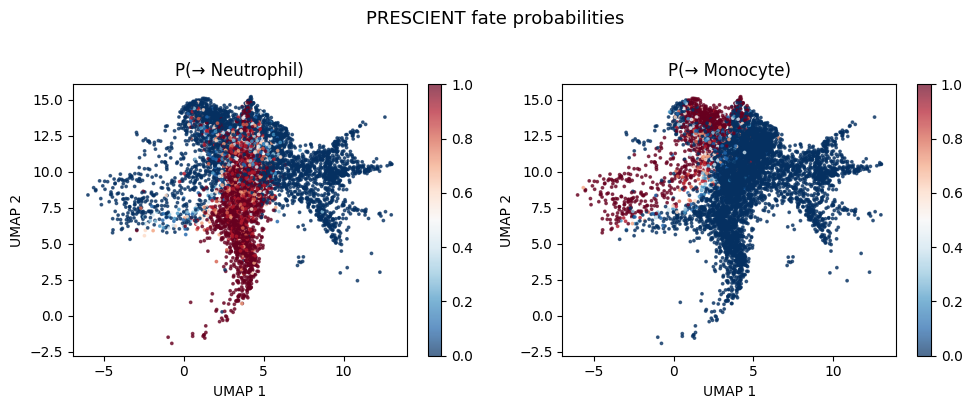

In [9]:
if "X_umap" in adata_d2.obsm:
    umap_d2 = adata_d2.obsm["X_umap"]
else:
    sc.pp.neighbors(adata_d2, n_neighbors=30, n_pcs=50, use_rep="X_pca")
    sc.tl.umap(adata_d2, random_state=SEED)
    umap_d2 = adata_d2.obsm["X_umap"]

# Show a few major lineages
show_lineages = [l for l in ["Neutrophil", "Monocyte", "Erythroid", "Lymphoid", "Meg", "Baso"] if l in branch_names]
ncols = min(len(show_lineages), 3)
nrows = (len(show_lineages) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, lin in enumerate(show_lineages):
    j = branch_names.index(lin)
    sc_ = axes[i].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                          c=fate_probs_df[lin].values, cmap="RdBu_r", vmin=0, vmax=1)
    plt.colorbar(sc_, ax=axes[i])
    axes[i].set_title(f"P(→ {lin})")
    axes[i].set_xlabel("UMAP 1")
    axes[i].set_ylabel("UMAP 2")

for ax in axes[len(show_lineages):]:
    ax.set_visible(False)

plt.suptitle("PRESCIENT fate probabilities", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 8. Evaluate against clonal ground-truth fate labels

For day-2 cells with clonal fate fractions we compare PRESCIENT's predicted lineage
probabilities to observed `fate_frac_*` values using the same metrics as notebook 02.


In [10]:
# Fate fractions were computed in notebook 01 and saved as fate_frac_* columns
fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
print(f"Fate fraction columns found: {len(fate_frac_cols)}")
for c in fate_frac_cols:
    print(f"  {c}")

has_fate = pd.Series(False, index=adata_d2.obs_names)
if fate_frac_cols:
    has_fate = adata_d2.obs[fate_frac_cols[0]].notna()
    n = has_fate.sum()
    print(f"\nDay-2 cells with ground-truth fate fractions: {n:,} / {adata_d2.n_obs:,}")
    if n > 0:
        print("\nMean fate fractions across cloned day-2 cells:")
        means = adata_d2.obs.loc[has_fate, fate_frac_cols].mean().sort_values(ascending=False)
        print(means.rename(lambda c: c.replace("fate_frac_", "")).round(3).to_string())
else:
    print("No fate_frac_* columns found in adata_d2.obs.")


Fate fraction columns found: 11
  fate_frac_Baso
  fate_frac_Ccr7_DC
  fate_frac_Eos
  fate_frac_Erythroid
  fate_frac_Lymphoid
  fate_frac_Mast
  fate_frac_Meg
  fate_frac_Monocyte
  fate_frac_Neutrophil
  fate_frac_Undifferentiated
  fate_frac_pDC

Day-2 cells with ground-truth fate fractions: 2,621 / 28,249

Mean fate fractions across cloned day-2 cells:
Undifferentiated    0.387
Neutrophil          0.231
Monocyte            0.205
Baso                0.084
Meg                 0.033
Lymphoid            0.025
Mast                0.017
Erythroid           0.006
Eos                 0.006
Ccr7_DC             0.005
pDC                 0.002


In [11]:
fate_df_norm = None

if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]
    print(f"Ground-truth fate matrix: {fate_df_norm.shape[0]:,} cells × {fate_df_norm.shape[1]} lineages")
    print(f"Lineages: {list(fate_df_norm.columns)}")
    print(fate_df_norm.head(3).round(3))
else:
    print("Skipping: no fate fractions available (see cell above).")


Ground-truth fate matrix: 2,621 cells × 11 lineages
Lineages: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil', 'Undifferentiated', 'pDC']
       Baso  Ccr7_DC  Eos  Erythroid  Lymphoid  Mast  Meg  Monocyte  \
13199   0.0      0.0  0.0        0.0       0.0   0.0  0.0     0.571   
13210   0.0      0.0  0.0        0.0       0.0   0.0  0.0     0.000   
13226   0.0      0.0  0.0        0.0       0.0   0.0  1.0     0.000   

       Neutrophil  Undifferentiated  pDC  
13199         0.0             0.429  0.0  
13210         1.0             0.000  0.0  
13226         0.0             0.000  0.0  


Cells with both predicted fate probs and fate labels: 2,621

Pearson r (observed fate fraction × predicted branch probability):
                  Neutrophil  Monocyte  Other
Baso                  -0.263    -0.112  0.345
Ccr7_DC               -0.053     0.141 -0.046
Eos                   -0.055    -0.039  0.084
Erythroid             -0.088    -0.039  0.116
Lymphoid              -0.064     0.239 -0.103
Mast                  -0.134    -0.061  0.178
Meg                   -0.192    -0.085  0.254
Monocyte               0.145     0.173 -0.268
Neutrophil             0.435    -0.209 -0.292
Undifferentiated      -0.192     0.060  0.152
pDC                   -0.049     0.105 -0.024


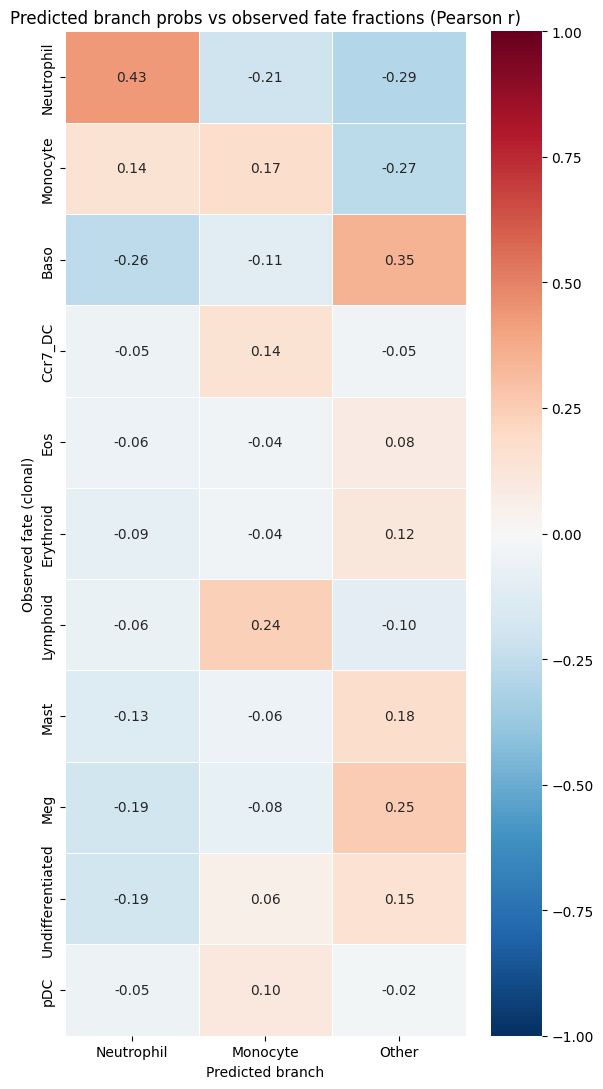

In [12]:
corr_df = None

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    branch_names = adata_d2.uns.get(
        "predicted_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    bp_df = pd.DataFrame(
        adata_d2.obsm[fate_prob_key],
        index=adata_d2.obs_names,
        columns=branch_names,
    )

    common = fate_df_norm.index.intersection(bp_df.index)
    print(f"Cells with both predicted fate probs and fate labels: {len(common):,}")
    fate_sub = fate_df_norm.loc[common]
    bp_sub   = bp_df.loc[common]

    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc].values, bp_sub[bc].values)

    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)
    print("\nPearson r (observed fate fraction × predicted branch probability):")
    print(corr_df.round(3).to_string())

    # Reorder rows: identified lineages aligned to diagonal, unidentified appended after
    identified = [c for c in corr_df.columns if c in corr_df.index]
    unidentified = [r for r in corr_df.index if r not in corr_df.columns]
    corr_df_plot = corr_df.loc[identified + unidentified]

    fig_w = max(6, len(bp_sub.columns))
    fig_h = max(4, len(fate_sub.columns))
    fig_h = max(4, len(corr_df_plot))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(corr_df_plot, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title("Predicted branch probs vs observed fate fractions (Pearson r)")
    ax.set_xlabel("Predicted branch")
    ax.set_ylabel("Observed fate (clonal)")
    plt.tight_layout()
    plt.savefig("prescient_corr_heatmap.png", dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping correlation heatmap: no fate fractions or branch probs available.")


>##### Observe diagonal for the first 6 rows/columns; Weinreb 2020 reports r ≈ 0.3–0.4 for methods that work.


Neu–Mono bias  Pearson r: 0.3519  (p=4.76e-39)
(Predicted Neu branch='Neutrophil', Predicted Mono branch='Monocyte')


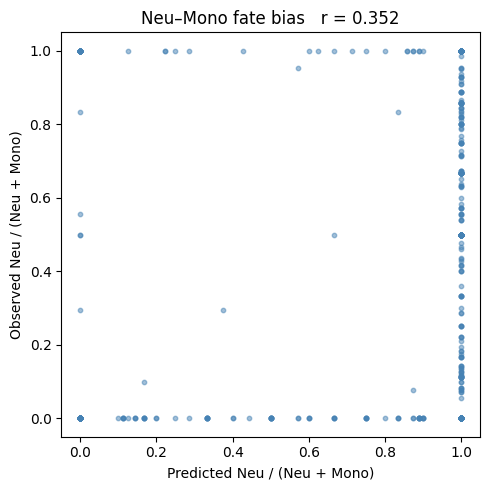

In [13]:
# Weinreb-style Neutrophil–Monocyte bias score
# Both observed and predicted are computed as Neu / (Neu + Mono).
NEU_KEYS = ["Neutrophil", "Neu"]
MONO_KEYS = ["Monocyte", "Mono"]

if fate_df_norm is not None and corr_df is not None:
    neu_col = next((c for c in fate_df_norm.columns if c in NEU_KEYS), None)
    mono_col = next((c for c in fate_df_norm.columns if c in MONO_KEYS), None)

    if neu_col and mono_col:
        obs_denom = fate_sub[neu_col] + fate_sub[mono_col]
        obs_bias = (fate_sub[neu_col] / obs_denom.replace(0, np.nan)).dropna()

        # Prefer explicit PRESCIENT branch names when present.
        if "Neutrophil" in bp_sub.columns and "Monocyte" in bp_sub.columns:
            pred_neu_branch = "Neutrophil"
            pred_mono_branch = "Monocyte"
        else:
            # Fallback: choose branches with strongest positive correlation,
            # excluding "Other" where possible.
            cand_cols = [c for c in corr_df.columns if c != "Other"] or list(corr_df.columns)
            pred_neu_branch = corr_df.loc[neu_col, cand_cols].idxmax()
            pred_mono_branch = corr_df.loc[mono_col, cand_cols].idxmax()
            if pred_mono_branch == pred_neu_branch:
                alt = corr_df.loc[mono_col, cand_cols].sort_values(ascending=False).index.tolist()
                if len(alt) > 1:
                    pred_mono_branch = alt[1]

        pred_neu = bp_sub.loc[obs_bias.index, pred_neu_branch]
        pred_mono = bp_sub.loc[obs_bias.index, pred_mono_branch]
        pred_denom = pred_neu + pred_mono
        pred_bias = (pred_neu / pred_denom.replace(0, np.nan)).dropna()

        common_bias = obs_bias.index.intersection(pred_bias.index)
        obs_vals = obs_bias.loc[common_bias].values
        pred_vals = pred_bias.loc[common_bias].values
        assert len(common_bias) > 10, "Too few cells with finite Neu-Mono bias for correlation."

        r, p = stats.pearsonr(pred_vals, obs_vals)

        print(f"Neu–Mono bias  Pearson r: {r:.4f}  (p={p:.2e})")
        print(
            f"(Predicted Neu branch='{pred_neu_branch}', "
            f"Predicted Mono branch='{pred_mono_branch}')"
        )

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(pred_vals, obs_vals, s=10, alpha=0.5, color="steelblue")
        ax.set_xlabel("Predicted Neu / (Neu + Mono)")
        ax.set_ylabel("Observed Neu / (Neu + Mono)")
        ax.set_title(f"Neu–Mono fate bias   r = {r:.3f}")
        plt.tight_layout()
        plt.savefig("prescient_neu_mono_bias.png", dpi=80, bbox_inches="tight")
        plt.show()
    else:
        print(f"Neu/Mono columns not in fate_df_norm. Available: {list(fate_df_norm.columns)}")
else:
    print("Skipping: correlation matrix not available.")



>##### Interpretation: among day-2 cells with clone assignments, many clones produce both Neutrophils and Monocytes at day 4/6. Some clones produce mostly Neutrophils, some mostly Monocytes. Can PRESCIENT detect it from gene expression alone? <br> Y axis - Neu / (Neu + Mono); for each cloned day-2 cell, what fraction of its clone's Neu+Mono descendants ended up as Neutrophils? 0 = pure Monocyte fate, 1 = pure Neutrophil fate. <br> X axis - Predicted P(Neutrophil branch) for that same cell (branch with highest |r| to observed Neutrophil in the Pearson matrix). <br> We expect points trending upward - cells assigned high predicted Neutrophil probability should also have high observed Neu fraction.


## 8c. Wasserstein-1 distance (per-cell fate distribution comparison)

Earth Mover's Distance between the predicted fate distribution and the observed clonal fate distribution, restricted to lineages present in both. Lower = better.

Ground cost is defined by UMAP geometry: each lineage is represented by the centroid of day-4/6 cells annotated as that lineage in `X_umap`, and transport cost between lineages is the Euclidean distance between those centroids. This matches the UMAP-distance OT metric used in the Palantir and MultistageOT notebooks for cross-model comparability.


Shared lineages (predicted branches ∩ observed fate labels): ['Monocyte', 'Neutrophil']
  (2 of 11 observed lineages covered by predicted branches)
UMAP-centroid ground metric built on 2 lineages: ['Monocyte', 'Neutrophil']

Wasserstein-1 distance (UMAP-centroid cost, 2 lineages, 1,295 cells):
  Mean:    2.9732
  Median:  0.0000
  Std:     3.4994


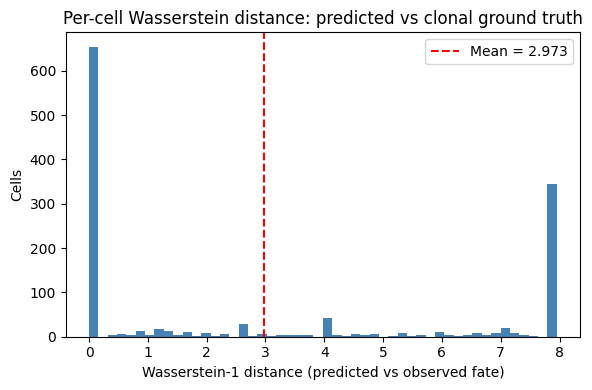

In [14]:
from scipy.optimize import linprog


def emd2_with_cost(a, b, C):
    """Optimal transport cost between distributions a and b under ground cost C."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    C = np.asarray(C, dtype=float)
    n = a.shape[0]

    c = C.reshape(-1)
    A_eq = []
    b_eq = []

    # Row constraints: sum_j T_ij = a_i
    for i in range(n):
        row = np.zeros(n * n)
        row[i * n:(i + 1) * n] = 1.0
        A_eq.append(row)
        b_eq.append(a[i])

    # Column constraints: sum_i T_ij = b_j
    for j in range(n):
        col = np.zeros(n * n)
        col[j::n] = 1.0
        A_eq.append(col)
        b_eq.append(b[j])

    res = linprog(
        c,
        A_eq=np.asarray(A_eq),
        b_eq=np.asarray(b_eq),
        bounds=(0, None),
        method="highs",
    )
    if not res.success:
        raise RuntimeError(f"OT solver failed: {res.message}")
    return float(res.fun)


if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    branch_names_wd = adata_d2.uns.get(
        "predicted_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    bp_df_wd = pd.DataFrame(
        adata_d2.obsm[fate_prob_key],
        index=adata_d2.obs_names,
        columns=branch_names_wd,
    )

    shared = sorted(set(fate_df_norm.columns) & set(bp_df_wd.columns))
    print(f"Shared lineages (predicted branches ∩ observed fate labels): {shared}")
    print(f"  ({len(shared)} of {len(fate_df_norm.columns)} observed lineages covered by predicted branches)")

    common_wd = fate_df_norm.index.intersection(bp_df_wd.index)
    fate_sub_wd = fate_df_norm.loc[common_wd, shared].values.astype(float)
    bp_sub_wd = bp_df_wd.loc[common_wd, shared].values.astype(float)

    # Use day-4/6 annotated cells to define lineage centroids in UMAP space.
    if "X_umap" not in adata_full.obsm:
        raise ValueError("X_umap missing in adata_full.obsm; cannot build UMAP-distance ground metric.")

    later_mask = (
        (adata_full.obs[time_col] > 2)
        & adata_full.obs[celltype_col].notna()
        & adata_full.obs[celltype_col].astype(str).isin(shared)
    ).values
    later_ct = adata_full.obs.loc[later_mask, celltype_col].astype(str).values
    later_umap = np.asarray(adata_full.obsm["X_umap"])[later_mask]

    centroids = {}
    missing_centroids = []
    for lin in shared:
        m = later_ct == lin
        if m.sum() == 0:
            missing_centroids.append(lin)
        else:
            centroids[lin] = later_umap[m].mean(axis=0)

    if missing_centroids:
        print(f"Skipping lineages without day-4/6 UMAP centroid: {missing_centroids}")
    shared_centroid = [lin for lin in shared if lin in centroids]
    assert len(shared_centroid) >= 2, "Need at least 2 lineages with UMAP centroids for OT distance."

    idx_keep = [shared.index(lin) for lin in shared_centroid]
    fate_sub_wd = fate_sub_wd[:, idx_keep]
    bp_sub_wd = bp_sub_wd[:, idx_keep]

    centroid_mat = np.vstack([centroids[lin] for lin in shared_centroid])
    diff = centroid_mat[:, None, :] - centroid_mat[None, :, :]
    C = np.sqrt((diff ** 2).sum(axis=2))

    print(f"UMAP-centroid ground metric built on {len(shared_centroid)} lineages: {shared_centroid}")
    if len(shared_centroid) < 6:
        print("WARNING: shared lineage set is < 6; check classifier mapping and available annotations.")

    per_cell_wd = []
    for obs_vec, pred_vec in zip(fate_sub_wd, bp_sub_wd):
        obs_s, pred_s = obs_vec.sum(), pred_vec.sum()
        if obs_s > 0 and pred_s > 0:
            a = obs_vec / obs_s
            b = pred_vec / pred_s
            per_cell_wd.append(emd2_with_cost(a, b, C))

    per_cell_wd = np.asarray(per_cell_wd, dtype=float)
    print(f"\nWasserstein-1 distance (UMAP-centroid cost, {len(shared_centroid)} lineages, {len(per_cell_wd):,} cells):")
    print(f"  Mean:    {per_cell_wd.mean():.4f}")
    print(f"  Median:  {np.median(per_cell_wd):.4f}")
    print(f"  Std:     {per_cell_wd.std():.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_wd, bins=50, color="steelblue", edgecolor="none")
    ax.axvline(per_cell_wd.mean(), color="red", linestyle="--",
               label=f"Mean = {per_cell_wd.mean():.3f}")
    ax.set_xlabel("Wasserstein-1 distance (predicted vs observed fate)")
    ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein distance: predicted vs clonal ground truth")
    ax.legend()
    plt.tight_layout()
    plt.savefig("prescient_wasserstein.png", dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: fate fractions or PRESCIENT probabilities not available.")


## 9. Save


In [15]:
print(f"Saving to {OUTPUT_H5AD} ...")
adata_d2.write_h5ad(OUTPUT_H5AD)

fate_probs_df.to_csv("prescient_day2_fate_probs.csv")
print("CSV saved to prescient_day2_fate_probs.csv")

result_cols = [c for c in adata_d2.obs.columns
               if c.startswith("fate_frac_") or c in [time_col, clone_col, celltype_col]]
adata_d2.obs[result_cols].join(fate_probs_df).to_csv("prescient_day2_results.csv")
print("CSV saved to prescient_day2_results.csv")


Saving to larry_day2_prescient.h5ad ...
CSV saved to prescient_day2_fate_probs.csv
CSV saved to prescient_day2_results.csv


In [16]:
print("=" * 55)
print("PRESCIENT ANALYSIS COMPLETE")
print("=" * 55)
print(f"  Training cells: {adata_train.n_obs:,}")
print(f"  Day-2 cells:    {adata_d2.n_obs:,}")
print(f"  Model dir:      {model_dir}")
print(f"  Branch names:   {adata_d2.uns.get('predicted_branch_names', 'N/A')}")
print(f"  Output h5ad:    {OUTPUT_H5AD}")


PRESCIENT ANALYSIS COMPLETE
  Training cells: 74,060
  Day-2 cells:    28,249
  Model dir:      prescient_models/cycling-softplus_2_500-1e-06/seed_42
  Branch names:   ['Neutrophil', 'Monocyte', 'Other']
  Output h5ad:    larry_day2_prescient.h5ad


---
## Eval-only checkpoint

Run the cell below on a **fresh kernel** to restore all variables needed by the section 8
eval cells without re-running training or simulation. Requires `larry_day2_prescient.h5ad`
and `prescient_day2_fate_probs.csv`.


In [17]:
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

warnings.filterwarnings("ignore")

OUTPUT_H5AD = "larry_day2_prescient.h5ad"
fate_prob_key = "prescient_fate_probabilities"

print(f"Loading {OUTPUT_H5AD} ...")
adata_d2 = anndata.read_h5ad(OUTPUT_H5AD)
fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
has_fate = (
    adata_d2.obs[fate_frac_cols[0]].notna()
    if fate_frac_cols
    else pd.Series(False, index=adata_d2.obs_names)
)

fate_df_norm = None
if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]

branch_names = (
    adata_d2.uns.get(
        "predicted_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    if fate_prob_key in adata_d2.obsm else []
)
bp_df = (
    pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names, columns=branch_names)
    if fate_prob_key in adata_d2.obsm else None
)
fate_probs_df = bp_df

corr_df = fate_sub = bp_sub = None
if fate_df_norm is not None and bp_df is not None:
    common = fate_df_norm.index.intersection(bp_df.index)
    fate_sub = fate_df_norm.loc[common]
    bp_sub = bp_df.loc[common]

    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc].values, bp_sub[bc].values)
    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)

print("\nAll eval-metric variables restored:")
print(f"  adata_d2     {adata_d2.n_obs:,} cells, obsm keys: {list(adata_d2.obsm.keys())}")
print(f"  fate_df_norm {fate_df_norm.shape if fate_df_norm is not None else None}")
print(f"  fate_sub     {fate_sub.shape if fate_sub is not None else None}")
print(f"  bp_sub       {bp_sub.shape if bp_sub is not None else None}")
print(f"  corr_df      {corr_df.shape if corr_df is not None else None}")
print(f"  branch_names {branch_names}")
print("\nReady — run any eval cell in section 8.")


Loading larry_day2_prescient.h5ad ...

All eval-metric variables restored:
  adata_d2     28,249 cells, obsm keys: ['X_cellcycle', 'X_clone', 'X_pca', 'X_umap', 'prescient_fate_probabilities']
  fate_df_norm (2621, 11)
  fate_sub     (2621, 11)
  bp_sub       (2621, 3)
  corr_df      (11, 3)
  branch_names ['Neutrophil' 'Monocyte' 'Other']

Ready — run any eval cell in section 8.


In [18]:
import os

# Search for any .pt files saved during the run
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.pt') or file.endswith('.pth'):
            print(os.path.join(root, file))

/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_001500.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/pretrain.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_000500.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_002000.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_002500.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.best.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_001000.pt
/content/prescient_models/cycling-softplus_2_500-1e-06/seed_42/config.pt
/content/drive/MyDrive/LARRY/data.pt
/content/drive/MyDrive/LARRY/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_002500.pt
/content/drive/MyDrive/LARRY/prescient_models/cycling-softplus_2_500-1e-06/seed_42/pretrain.pt
/content/drive/MyDrive/LARRY/prescient_models/cycling-softplus_2_500-1e-06/seed_42/train.epoch_002000.pt
/content

### Fast rerun path (`RETRAIN=False`)

When re-running without retraining, use this order:
1. **Section 4** data prep (safe to rerun; relatively fast)
2. **Section 6** model load + classifier setup (loads from `SAVED_MODEL_DIR`)
3. **Section 7** simulation (`SIM_EVALUABLE_ONLY=True` runs only evaluable day-2 cells)
4. **Section 8** evaluation (Pearson grid, Neu-Mono bias, UMAP-distance Wasserstein)

Skip section 5 training when `RETRAIN=False`.

In [19]:
import shutil

# Copy preprocessed data
shutil.copy(
    '/content/prescient_data/data.pt',
    '/content/drive/MyDrive/LARRY/data.pt'
)

# Copy entire model folder
shutil.copytree(
    '/content/prescient_models',
    '/content/drive/MyDrive/LARRY/prescient_models',
    dirs_exist_ok=True
)

print("Saved to Drive successfully.")

Saved to Drive successfully.
